Реальный кейс на Python: Сжатие 10 признаков в 2 компоненты

Давайте создадим датасет, где у клиентов будет **10 различных признаков**   
(оценки сервиса, активность, траты в разных категориях), сожмем их до **2 компонент**   
с помощью PCA и визуализируем на обычном плоском графике.

Шаг 1: Генерация многомерных данных и масштабирование  

PCA, как и K-Means, крайне чувствителен к масштабу.   
Поэтому перед его применением данные всегда нужно   
стандартизировать (обычно используют StandardScaler,   
который приводит среднее к 0, а дисперсию к 1).

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Генерируем 1000 клиентов и 10 признаков для каждого
np.random.seed(42)
n_customers = 1000
n_features = 10

# Создаем случайную матрицу данных
matrix = np.random.rand(n_customers, n_features)
columns = [f'Feature_{i}' for i in range(1, n_features + 1)]
df_high_dim = pd.DataFrame(matrix, columns=columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_high_dim)
print(f"Исходная форма данных: {X_scaled.shape} (1000 клиентов, 10 признаков)")

Исходная форма данных: (1000, 10) (1000 клиентов, 10 признаков)


Шаг 2: Применение PCA - Сжимаем 10 признаков в 2 главные компоненты.

In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
print(f"Новая форма данных после PCA: {X_pca.shape} (1000 клиентов, всего 2 признака!)")

Новая форма данных после PCA: (1000, 2) (1000 клиентов, всего 2 признака!)


Шаг 3: Сколько информации мы сохранили?

Важнейшая метрика в PCA — **explained_variance_ratio_** (доля объясненной дисперсии).  
Она показывает, какой процент информации из исходных 10 колонок нам удалось удержать в этих двух.

In [7]:
# Смотрим процент сохраненной информации
variance_ratio = pca.explained_variance_ratio_
print(f"Первая компонента сохранила: {variance_ratio[0]*100:.1f}% информации")
print(f"Вторая компонента сохранила: {variance_ratio[1]*100:.1f}% информации")
print(f"Суммарно сохранено: {sum(variance_ratio)*100:.1f}% исходной информации")


Первая компонента сохранила: 11.5% информации
Вторая компонента сохранила: 11.2% информации
Суммарно сохранено: 22.7% исходной информации


Примечание: Если данные абсолютно случайны (как в нашем примере),  
процент будет невысоким (около 20-25%). В реальных же задачах,   
где признаки взаимосвязаны (например, возраст и доход часто коррелируют),  
2-3 компоненты могут легко удерживать 80-90% всей информации.

---

Шаг 4: Визуализация и кластеризация сжатых данных

Теперь мы можем запустить наш любимый K-Means уже на сжатых данных (X_pca) и легко построить красивый 2D-график!

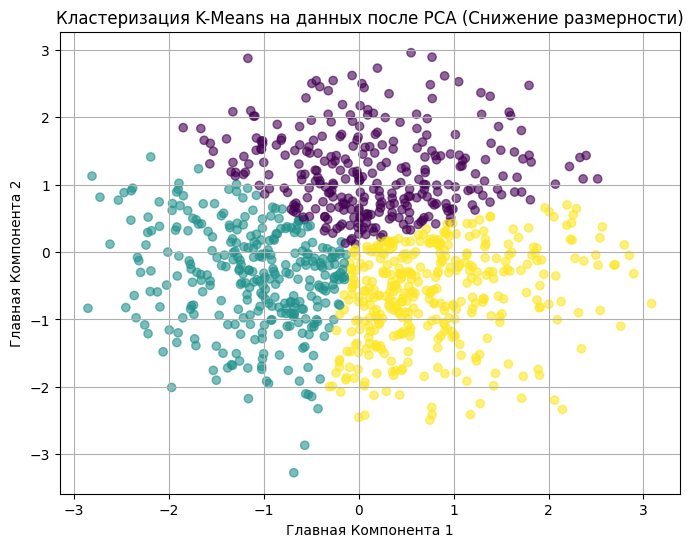

In [8]:
from sklearn.cluster import KMeans

# Кластеризуем данные, которые предварительно сжал PCA
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Строим обычный 2D график
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.6)
plt.xlabel('Главная Компонента 1')
plt.ylabel('Главная Компонента 2')
plt.title('Кластеризация K-Means на данных после PCA (Снижение размерности)')
plt.grid(True)
plt.show()


#### t-SNE, UMAP